# NeuroScope AI - Notebook 05: Lung Nodule Detection

Two-stage pipeline on LUNA16:
1. False Positive Reduction -- 3D CNN classifies candidates as nodule/non-nodule
2. Lung-RADS scoring -- malignancy estimation from nodule characteristics

Key challenge: 600:1 class imbalance (non-nodules vs nodules)
Solution: WeightedRandomSampler + Focal Loss

Datasets:
- LUNA16 (888 CT scans, 10 subsets)
- candidates_V2.csv (~550K candidates)
- annotations.csv (~1,200 confirmed nodules)

Estimated runtime on RTX 4060:
- Candidate loading + preprocessing: ~10 min (one-time)
- ~15-20 min per epoch
- 30 epochs total ~ 8-10 hours

---

## Cell 1 - Imports & Config

In [18]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import SimpleITK as sitk
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
CKPT = os.path.join(BASE, 'checkpoints', 'lung_det')
OUT  = os.path.join(BASE, 'outputs', 'nb05_lung_det')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print('Imports OK')

Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
Imports OK


---
## Cell 2 - Training Config

In [19]:
BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS        = os.path.join(BASE, 'datasets')
LUNA_PATH = os.path.join(DS, 'lung', 'luna16')

# Patch extraction
PATCH_SIZE    = 32
VOXEL_SPACING = 1.0

# Training
BATCH_SIZE   = 64
MAX_EPOCHS   = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.15
NUM_WORKERS  = 0
AMP          = True

# Sampling -- keep all positives, cap negatives
MAX_NEG_TRAIN = 20000   # ~17x positives, much faster than 470K
MAX_NEG_VAL   = 5000

# Lung HU window
HU_MIN = -1000.0
HU_MAX =  400.0

print(f'LUNA16 path  : {LUNA_PATH}')
print(f'Patch size   : {PATCH_SIZE}^3')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max neg train: {MAX_NEG_TRAIN:,}')
print(f'Max neg val  : {MAX_NEG_VAL:,}')

LUNA16 path  : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\lung\luna16
Patch size   : 32^3
Batch size   : 64
Max neg train: 20,000
Max neg val  : 5,000


---
## Cell 3 - Load & Inspect Annotations

In [20]:
import os, pandas as pd, numpy as np

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
LUNA_PATH = os.path.join(BASE, 'datasets', 'lung', 'luna16')

# Find CSV files
ann_path  = None
cand_path = None
for root, dirs, files in os.walk(LUNA_PATH):
    for f in files:
        if f == 'annotations.csv':    ann_path  = os.path.join(root, f)
        if f == 'candidates_V2.csv':  cand_path = os.path.join(root, f)

print(f'annotations.csv   : {ann_path}')
print(f'candidates_V2.csv : {cand_path}')

assert ann_path  is not None, 'annotations.csv not found - download from luna16.grand-challenge.org'
assert cand_path is not None, 'candidates_V2.csv not found - download from luna16.grand-challenge.org'

df_ann  = pd.read_csv(ann_path)
df_cand = pd.read_csv(cand_path)

print(f'\nAnnotations (confirmed nodules):')
print(f'  Rows    : {len(df_ann):,}')
print(f'  Columns : {list(df_ann.columns)}')
print(df_ann.head(3))

print(f'\nCandidates:')
print(f'  Rows    : {len(df_cand):,}')
print(f'  Columns : {list(df_cand.columns)}')
vc = df_cand['class'].value_counts()
print(f'  Class 1 (nodule)     : {vc.get(1, 0):,}')
print(f'  Class 0 (non-nodule) : {vc.get(0, 0):,}')
ratio = vc.get(0, 0) / max(vc.get(1, 1), 1)
print(f'  Imbalance ratio      : {ratio:.0f}:1')

# Find MHD files
mhd_files = {}
for root, dirs, files in os.walk(LUNA_PATH):
    for f in files:
        if f.endswith('.mhd'):
            uid = os.path.splitext(f)[0]
            mhd_files[uid] = os.path.join(root, f)

print(f'\nMHD CT scans found: {len(mhd_files)}')
print(f'Scans in candidates: {df_cand["seriesuid"].nunique()}')

# Match candidates to available scans
available_uids = set(mhd_files.keys())
cand_uids      = set(df_cand['seriesuid'].unique())
matched        = available_uids & cand_uids
print(f'Matched (both MHD and candidates): {len(matched)}')

annotations.csv   : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\lung\luna16\annotations.csv
candidates_V2.csv : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\lung\luna16\candidates_V2.csv

Annotations (confirmed nodules):
  Rows    : 1,186
  Columns : ['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  

Candidates:
  Rows    : 754,975
  Columns : ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']
  Class 1 (nodule)     : 1,557
  Class 0 (non-nodule) : 753,418
  Imbalance ratio      : 484:1

MHD CT scans found: 888
Sc

---
## Cell 4 - LUNA16 Dataset (On-The-Fly Patch Extraction)

In [28]:
import os, torch, numpy as np, pandas as pd
import SimpleITK as sitk
from torch.utils.data import Dataset

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
LUNA_PATH = os.path.join(BASE, 'datasets', 'lung', 'luna16')
PATCH_SIZE = 32
HU_MIN     = -1000.0
HU_MAX     =  400.0
MAX_NEG_TRAIN = 20000
MAX_NEG_VAL   = 5000


def load_mhd(path):
    """
    Load .mhd CT scan using SimpleITK.
    Returns: numpy array [Z, Y, X], origin [x,y,z], spacing [x,y,z]
    """
    itk_img = sitk.ReadImage(path)
    arr     = sitk.GetArrayFromImage(itk_img).astype(np.float32)  # [Z, Y, X]
    origin  = np.array(itk_img.GetOrigin())    # [x, y, z]
    spacing = np.array(itk_img.GetSpacing())   # [x, y, z] mm per voxel
    return arr, origin, spacing


def world_to_voxel(coord_world, origin, spacing):
    """
    Convert world coordinates (mm) to voxel indices.
    LUNA16 coords are [x, y, z] in mm.
    Array indexing is [z, y, x].
    """
    coord_voxel = (coord_world - origin) / spacing  # [x, y, z]
    return coord_voxel[[2, 1, 0]].astype(int)       # [z, y, x] for array indexing


def extract_patch(volume, center_vox, patch_size=32):
    """
    Extract a cubic patch of shape [patch_size, patch_size, patch_size]
    centered at center_vox [z, y, x].
    Pads with HU_MIN if patch extends outside volume.
    """
    half  = patch_size // 2
    cz, cy, cx = center_vox

    z0, z1 = cz - half, cz + half
    y0, y1 = cy - half, cy + half
    x0, x1 = cx - half, cx + half

    # Pad volume if needed
    pad_z = (max(0, -z0), max(0, z1 - volume.shape[0]))
    pad_y = (max(0, -y0), max(0, y1 - volume.shape[1]))
    pad_x = (max(0, -x0), max(0, x1 - volume.shape[2]))

    if any(p[0] > 0 or p[1] > 0 for p in [pad_z, pad_y, pad_x]):
        volume = np.pad(volume, (pad_z, pad_y, pad_x),
                        mode='constant', constant_values=HU_MIN)
        cz += pad_z[0]
        cy += pad_y[0]
        cx += pad_x[0]

    patch = volume[cz-half:cz+half, cy-half:cy+half, cx-half:cx+half]

    # Ensure correct shape
    if patch.shape != (patch_size, patch_size, patch_size):
        patch = np.zeros((patch_size, patch_size, patch_size), dtype=np.float32) + HU_MIN

    return patch


def normalize_hu(patch, hu_min=HU_MIN, hu_max=HU_MAX):
    patch = np.clip(patch, hu_min, hu_max)
    return (patch - hu_min) / (hu_max - hu_min)


class LUNADataset(Dataset):
    """
    LUNA16 nodule detection dataset.
    Extracts 3D patches on-the-fly from MHD CT scans.

    Strategy: Build a sample list of (mhd_path, world_coord, label).
    At __getitem__ time, load the CT scan, extract the patch, normalize.

    CT scans are NOT cached (888 scans x ~50MB = 44GB RAM needed).
    This is slower per-step but avoids RAM overflow.
    """
    def __init__(self, mhd_files, df_candidates, patch_size=32,
                 mode='train', augment=True):
        self.mhd_files  = mhd_files
        self.patch_size = patch_size
        self.mode       = mode
        self.augment    = augment and mode == 'train'
        self.samples    = []

        # Build sample list
        for _, row in df_candidates.iterrows():
            uid = row['seriesuid']
            if uid not in mhd_files:
                continue
            coord_world = np.array([row['coordX'], row['coordY'], row['coordZ']])
            label       = int(row['class'])
            self.samples.append((mhd_files[uid], coord_world, label))

        pos = sum(1 for s in self.samples if s[2] == 1)
        neg = sum(1 for s in self.samples if s[2] == 0)
        print(f'LUNA [{mode}]: {len(self.samples):,} samples '
              f'(+{pos:,} nodules, -{neg:,} non-nodules, ratio {neg//max(pos,1)}:1)')

    def __len__(self):
        return len(self.samples)

    def get_sampler_weights(self):
        labels  = [s[2] for s in self.samples]
        counts  = Counter(labels)
        weights = [1.0 / counts[l] for l in labels]
        return torch.tensor(weights, dtype=torch.double)

    def __getitem__(self, idx):
        mhd_path, coord_world, label = self.samples[idx]

        try:
            volume, origin, spacing = load_mhd(mhd_path)
            center_vox = world_to_voxel(coord_world, origin, spacing)
            patch      = extract_patch(volume, center_vox, self.patch_size)
            patch      = normalize_hu(patch)
        except Exception as e:
            patch = np.zeros((self.patch_size,)*3, dtype=np.float32)

        if self.augment:
            # Random flips on all 3 axes
            for axis in range(3):
                if np.random.rand() > 0.5:
                    patch = np.flip(patch, axis=axis).copy()
            # Random 90-degree rotations
            k = np.random.randint(0, 4)
            if k > 0:
                patch = np.rot90(patch, k=k, axes=(0, 1)).copy()

        # Add channel dim: [1, D, H, W]
        patch_t = torch.from_numpy(patch).unsqueeze(0).float()
        return patch_t, label


# ── Build datasets ────────────────────────────────────────────────────────
print('Building LUNA16 datasets...')

# Load CSVs
ann_path  = next(p for r,d,f in os.walk(LUNA_PATH) for fn in f if fn == 'annotations.csv'
                 for p in [os.path.join(r, fn)])
cand_path = next(p for r,d,f in os.walk(LUNA_PATH) for fn in f if fn == 'candidates_V2.csv'
                 for p in [os.path.join(r, fn)])

df_ann  = pd.read_csv(ann_path)
df_cand = pd.read_csv(cand_path)

# Build MHD file lookup
mhd_files = {}
for root, dirs, files in os.walk(LUNA_PATH):
    for f in files:
        if f.endswith('.mhd'):
            mhd_files[os.path.splitext(f)[0]] = os.path.join(root, f)

print(f'MHD files found: {len(mhd_files)}')

# Filter candidates to available scans
available = set(mhd_files.keys())
df_cand   = df_cand[df_cand['seriesuid'].isin(available)].reset_index(drop=True)
print(f'Candidates after filtering: {len(df_cand):,}')

# Train/val split by seriesuid
all_uids         = df_cand['seriesuid'].unique()
tr_uids, va_uids = train_test_split(all_uids, test_size=0.15, random_state=42)
df_tr = df_cand[df_cand['seriesuid'].isin(tr_uids)].reset_index(drop=True)
df_va = df_cand[df_cand['seriesuid'].isin(va_uids)].reset_index(drop=True)

# Subsample negatives -- keep ALL positives, cap negatives
MAX_NEG_TRAIN = 20000
MAX_NEG_VAL   = 5000

pos_tr = df_tr[df_tr['class'] == 1]
neg_tr = df_tr[df_tr['class'] == 0].sample(n=min(MAX_NEG_TRAIN, len(df_tr[df_tr['class']==0])), random_state=42)
df_tr  = pd.concat([pos_tr, neg_tr]).sample(frac=1, random_state=42).reset_index(drop=True)

pos_va = df_va[df_va['class'] == 1]
neg_va = df_va[df_va['class'] == 0].sample(n=min(MAX_NEG_VAL, len(df_va[df_va['class']==0])), random_state=42)
df_va  = pd.concat([pos_va, neg_va]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Train: {len(df_tr):,}  (+{len(pos_tr):,} nodules, -{len(neg_tr):,} non-nodules)')
print(f'Val  : {len(df_va):,}  (+{len(pos_va):,} nodules, -{len(neg_va):,} non-nodules)')

tr_ds = LUNADataset(mhd_files, df_tr, PATCH_SIZE, 'train', augment=True)
va_ds = LUNADataset(mhd_files, df_va, PATCH_SIZE, 'val',   augment=False)

# Manual oversampling -- duplicate positives to balance classes
# Much faster than WeightedRandomSampler on Windows
pos_samples = [s for s in tr_ds.samples if s[2] == 1]
neg_samples = [s for s in tr_ds.samples if s[2] == 0]
repeats     = len(neg_samples) // max(len(pos_samples), 1)
balanced    = neg_samples + pos_samples * repeats
np.random.shuffle(balanced)
tr_ds.samples = balanced

print(f'Balanced train: {len(tr_ds.samples):,} '
      f'(+{len(pos_samples)*repeats:,} pos, -{len(neg_samples):,} neg)')

# Plain shuffle -- no sampler needed
tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

# Benchmark
import time
t0    = time.time()
patch, label = next(iter(tr_dl))
t1    = time.time()
steps = len(tr_dl)
print(f'Batch time : {t1-t0:.2f}s')
print(f'Steps/epoch: {steps}')
print(f'Est. epoch : {steps*(t1-t0)/60:.1f} min')
print(f'Pos in batch: {label.sum().item()}/{len(label)}')
print('Dataset OK')

Building LUNA16 datasets...
MHD files found: 888
Candidates after filtering: 754,975
Train: 21,359  (+1,359 nodules, -20,000 non-nodules)
Val  : 5,198  (+198 nodules, -5,000 non-nodules)
LUNA [train]: 21,359 samples (+1,359 nodules, -20,000 non-nodules, ratio 14:1)
LUNA [val]: 5,198 samples (+198 nodules, -5,000 non-nodules, ratio 25:1)
Balanced train: 39,026 (+19,026 pos, -20,000 neg)
Batch time : 24.09s
Steps/epoch: 610
Est. epoch : 244.9 min
Pos in batch: 29/64
Dataset OK


In [34]:
import torch, numpy as np, os
from torch.utils.data import TensorDataset, DataLoader

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CACHE_DIR = os.path.join(BASE, 'datasets', 'lung', 'luna16_patches')
BATCH_SIZE = 64
NUM_WORKERS = 0

tr_patches = torch.from_numpy(np.load(os.path.join(CACHE_DIR, 'train_patches.npy')))
tr_labels  = torch.from_numpy(np.load(os.path.join(CACHE_DIR, 'train_labels.npy')))
va_patches = torch.from_numpy(np.load(os.path.join(CACHE_DIR, 'val_patches.npy')))
va_labels  = torch.from_numpy(np.load(os.path.join(CACHE_DIR, 'val_labels.npy')))

print(f'Train patches: {tr_patches.shape}  labels: {tr_labels.shape}')
print(f'Val   patches: {va_patches.shape}  labels: {va_labels.shape}')
print(f'Train pos: {tr_labels.sum().item():,}  neg: {(tr_labels==0).sum().item():,}')

tr_dl = DataLoader(TensorDataset(tr_patches, tr_labels),
                   batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True)
va_dl = DataLoader(TensorDataset(va_patches, va_labels),
                   batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

# Benchmark
import time
t0 = time.time()
p, l = next(iter(tr_dl))
t1 = time.time()
print(f'Batch time : {t1-t0:.3f}s')
print(f'Steps/epoch: {len(tr_dl)}')
print(f'Est. epoch : {len(tr_dl)*(t1-t0)/60:.1f} min')
print('DataLoaders OK')

Train patches: torch.Size([39026, 1, 32, 32, 32])  labels: torch.Size([39026])
Val   patches: torch.Size([5198, 1, 32, 32, 32])  labels: torch.Size([5198])
Train pos: 19,026  neg: 20,000
Batch time : 0.011s
Steps/epoch: 610
Est. epoch : 0.1 min
DataLoaders OK


---
## Cell 5 - 3D CNN Model (Nodule Detector)

In [35]:
import torch
import torch.nn as nn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class ResBlock3D(nn.Module):
    """3D Residual block for volumetric feature extraction."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm3d(out_ch)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv2(self.conv1(x)) + self.shortcut(x))


class NoduleDetector(nn.Module):
    """
    3D ResNet for false positive reduction.
    Input:  [B, 1, 32, 32, 32] -- single-channel CT patch
    Output: [B, 2] -- logits for [non-nodule, nodule]

    Architecture inspired by DeepLung (Zhu et al. 2018)
    but simplified for 8GB VRAM.
    """
    def __init__(self, in_channels=1, num_classes=2, dropout=0.3):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
        )

        # Residual stages
        self.stage1 = ResBlock3D(32,  64,  stride=2)  # 32->16
        self.stage2 = ResBlock3D(64,  128, stride=2)  # 16->8
        self.stage3 = ResBlock3D(128, 256, stride=2)  # 8->4
        self.stage4 = ResBlock3D(256, 256, stride=2)  # 4->2

        # Global average pooling + classifier
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        return self.classifier(x)


model = NoduleDetector(in_channels=1, num_classes=2, dropout=0.3).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model       : NoduleDetector (3D ResNet)')
print(f'Parameters  : {n_params:,}')

# Test forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 1, 32, 32, 32).to(DEVICE)
    out   = model(dummy)
    print(f'Forward     : {dummy.shape} -> {out.shape}')
    del dummy, out
    torch.cuda.empty_cache()
print('Model OK')

Model       : NoduleDetector (3D ResNet)
Parameters  : 7,169,442
Forward     : torch.Size([2, 1, 32, 32, 32]) -> torch.Size([2, 2])
Model OK


---
## Cell 6 - Focal Loss + Optimizer

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 30
AMP          = True


class FocalLoss(nn.Module):
    """
    Focal Loss for extreme class imbalance.
    alpha: weight for positive class (nodule)
    gamma: focusing parameter -- higher = focus more on hard examples

    With 600:1 imbalance, standard CrossEntropy achieves 99.8% accuracy
    by predicting all-negative. Focal Loss forces the model to learn
    the rare positive class.
    """
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt      = torch.exp(-ce_loss)
        alpha_t = torch.where(targets == 1,
                              torch.tensor(self.alpha, device=logits.device),
                              torch.tensor(1 - self.alpha, device=logits.device))
        focal   = alpha_t * ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()


loss_fn   = FocalLoss(alpha=0.75, gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)
scaler    = GradScaler(enabled=AMP)

print('Loss      : FocalLoss (alpha=0.75, gamma=2.0)')
print('Optimizer : AdamW')
print('Scheduler : CosineAnnealingLR')
print('OK')

Loss      : FocalLoss (alpha=0.75, gamma=2.0)
Optimizer : AdamW
Scheduler : CosineAnnealingLR
OK


---
## Cell 7 - Checkpoint Utilities

In [37]:
import os, torch, json

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'lung_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_auc, history, tag='last'):
    path = os.path.join(CKPT, f'lung_det_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
        'best_auc': best_auc,
        'history': history,
    }, path)
    json_path = os.path.join(CKPT, f'lung_det_{tag}_summary.json')
    with open(json_path, 'w') as f:
        json.dump({'epoch': epoch, **metrics, 'best_auc': best_auc}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'lung_det_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch    = ckpt['epoch']
    best_auc = ckpt.get('best_auc', 0.0)
    history  = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_auc={best_auc:.4f}')
    return epoch + 1, best_auc, history


for tag in ['last', 'best']:
    p = os.path.join(CKPT, f'lung_det_{tag}.pth')
    print(f'  {tag}.pth : {"EXISTS" if os.path.exists(p) else "not found"}')
print('Checkpoint utilities OK')

  last.pth : not found
  best.pth : not found
Checkpoint utilities OK


In [33]:
import os, numpy as np, pandas as pd, SimpleITK as sitk
from pathlib import Path
import time

BASE       = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
LUNA_PATH  = os.path.join(BASE, 'datasets', 'lung', 'luna16')
CACHE_DIR  = os.path.join(BASE, 'datasets', 'lung', 'luna16_patches')
os.makedirs(CACHE_DIR, exist_ok=True)

PATCH_SIZE = 32
HU_MIN     = -1000.0
HU_MAX     =  400.0

def load_mhd(path):
    itk = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(itk).astype(np.float32)
    return arr, np.array(itk.GetOrigin()), np.array(itk.GetSpacing())

def world_to_voxel(coord, origin, spacing):
    v = (coord - origin) / spacing
    return v[[2,1,0]].astype(int)

def extract_patch(vol, ctr, ps=32):
    h = ps // 2
    cz, cy, cx = ctr
    pz = (max(0,-cz+h), max(0,cz+h-vol.shape[0]))
    py = (max(0,-cy+h), max(0,cy+h-vol.shape[1]))
    px = (max(0,-cx+h), max(0,cx+h-vol.shape[2]))
    if any(p[0]>0 or p[1]>0 for p in [pz,py,px]):
        vol = np.pad(vol,(pz,py,px),mode='constant',constant_values=HU_MIN)
        cz+=pz[0]; cy+=py[0]; cx+=px[0]
    patch = vol[cz-h:cz+h, cy-h:cy+h, cx-h:cx+h]
    if patch.shape != (ps,ps,ps):
        patch = np.full((ps,ps,ps), HU_MIN, dtype=np.float32)
    patch = np.clip(patch, HU_MIN, HU_MAX)
    return (patch - HU_MIN) / (HU_MAX - HU_MIN)

# Load all samples from tr_ds and va_ds
print('Extracting patches to disk...')
print('This runs once (~5-10 min) then training is fast forever.')

for split_name, ds in [('train', tr_ds), ('val', va_ds)]:
    patches_path = os.path.join(CACHE_DIR, f'{split_name}_patches.npy')
    labels_path  = os.path.join(CACHE_DIR, f'{split_name}_labels.npy')

    if os.path.exists(patches_path):
        print(f'{split_name}: already cached, skipping')
        continue

    n       = len(ds.samples)
    patches = np.zeros((n, 1, PATCH_SIZE, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
    labels  = np.zeros(n, dtype=np.int64)

    # Group by MHD file to minimize file loads
    from collections import defaultdict
    groups = defaultdict(list)
    for i, (mhd_path, coord, label) in enumerate(ds.samples):
        groups[mhd_path].append((i, coord, label))

    t0      = time.time()
    done    = 0
    n_files = len(groups)

    for fi, (mhd_path, items) in enumerate(groups.items()):
        try:
            vol, origin, spacing = load_mhd(mhd_path)
        except Exception:
            done += len(items)
            continue

        for idx, coord, label in items:
            ctr            = world_to_voxel(coord, origin, spacing)
            patches[idx,0] = extract_patch(vol, ctr, PATCH_SIZE)
            labels[idx]    = label
            done          += 1

        if (fi+1) % 50 == 0:
            elapsed = time.time() - t0
            eta     = elapsed / (fi+1) * (n_files - fi - 1)
            print(f'  {split_name}: {fi+1}/{n_files} scans | {done:,}/{n} patches | ETA {eta/60:.1f}min')

    np.save(patches_path, patches)
    np.save(labels_path,  labels)
    sz = (patches.nbytes + labels.nbytes) / (1024**3)
    print(f'{split_name}: saved {n:,} patches ({sz:.2f} GB) -> {patches_path}')

print('Extraction complete')

Extracting patches to disk...
This runs once (~5-10 min) then training is fast forever.
  train: 50/754 scans | 3,733/39026 patches | ETA 8.2min
  train: 100/754 scans | 7,289/39026 patches | ETA 5.9min
  train: 150/754 scans | 10,964/39026 patches | ETA 5.0min
  train: 200/754 scans | 14,285/39026 patches | ETA 4.5min
  train: 250/754 scans | 17,600/39026 patches | ETA 4.0min
  train: 300/754 scans | 20,592/39026 patches | ETA 3.5min
  train: 350/754 scans | 23,365/39026 patches | ETA 3.0min
  train: 400/754 scans | 26,254/39026 patches | ETA 2.7min
  train: 450/754 scans | 28,876/39026 patches | ETA 2.3min
  train: 500/754 scans | 31,217/39026 patches | ETA 2.1min
  train: 550/754 scans | 33,354/39026 patches | ETA 1.6min
  train: 600/754 scans | 35,183/39026 patches | ETA 1.2min
  train: 650/754 scans | 36,649/39026 patches | ETA 0.8min
  train: 700/754 scans | 38,035/39026 patches | ETA 0.5min
  train: 750/754 scans | 38,997/39026 patches | ETA 0.0min
train: saved 39,026 patches (4

---
## Cell 8 - Training Loop

In [38]:
import os, time, torch, numpy as np
from torch.cuda.amp import autocast
from sklearn.metrics import roc_auc_score

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 30
AMP        = True
BASE       = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT       = os.path.join(BASE, 'checkpoints', 'lung_det')

# Resume
start_epoch, best_auc, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch : {start_epoch}')
print(f'Max epochs          : {MAX_EPOCHS}')
print('-' * 65)


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # ── TRAIN ─────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    n_steps    = 0

    for step, (patches, labels) in enumerate(tr_dl):
        patches = patches.to(DEVICE)
        labels  = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=AMP):
            logits = model(patches)
            loss   = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_steps    += 1

        if (step + 1) % 200 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:5d}/{len(tr_dl)} '
                  f'| Loss {train_loss/n_steps:.4f}')

    scheduler.step()
    avg_loss = train_loss / n_steps

    # ── VALIDATE ──────────────────────────────────────────────────────────
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for patches, labels in va_dl:
            patches = patches.to(DEVICE)
            logits  = model(patches)
            probs   = torch.softmax(logits, dim=1)[:, 1]  # prob of nodule
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # AUC is the right metric for imbalanced detection
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0

    # Sensitivity at high specificity (clinically relevant)
    threshold   = np.percentile(all_probs, 90)  # top 10% flagged
    preds_bin   = (all_probs >= threshold).astype(int)
    tp = ((preds_bin == 1) & (all_labels == 1)).sum()
    fn = ((preds_bin == 0) & (all_labels == 1)).sum()
    sensitivity = tp / max(tp + fn, 1)

    elapsed = time.time() - t0
    metrics = {
        'train_loss':  avg_loss,
        'val_auc':     float(auc),
        'sensitivity': float(sensitivity),
    }

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} '
          f'| Loss {avg_loss:.4f} '
          f'| AUC {auc:.4f} '
          f'| Sensitivity {sensitivity:.4f} '
          f'| {elapsed/60:.1f}min')

    history.append({'epoch': epoch+1, **metrics})

    if auc > best_auc:
        best_auc = auc
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        metrics, best_auc, history, tag='best')
        print(f'  --> New best AUC={best_auc:.4f}')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_auc, history, tag='last')


print()
print('=' * 65)
print(f'Training complete! Best AUC: {best_auc:.4f}')
print('=' * 65)

No checkpoint at C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\lung_det\lung_det_last.pth - starting from scratch
Starting from epoch : 0
Max epochs          : 30
-----------------------------------------------------------------
  Epoch   1 | Step   200/610 | Loss 0.0408
  Epoch   1 | Step   400/610 | Loss 0.0305
  Epoch   1 | Step   600/610 | Loss 0.0243
Epoch   1/30 | Loss 0.0241 | AUC 0.9772 | Sensitivity 0.8990 | 0.8min
  --> New best AUC=0.9772
  Epoch   2 | Step   200/610 | Loss 0.0075
  Epoch   2 | Step   400/610 | Loss 0.0076
  Epoch   2 | Step   600/610 | Loss 0.0068
Epoch   2/30 | Loss 0.0068 | AUC 0.9760 | Sensitivity 0.9242 | 0.8min
  Epoch   3 | Step   200/610 | Loss 0.0044
  Epoch   3 | Step   400/610 | Loss 0.0040
  Epoch   3 | Step   600/610 | Loss 0.0036
Epoch   3/30 | Loss 0.0036 | AUC 0.9760 | Sensitivity 0.8990 | 0.8min
  Epoch   4 | Step   200/610 | Loss 0.0029
  Epoch   4 | Step   400/610 | Loss 0.0025
  Epoch   4 | Step   600/610 | Loss 0.0025
E

---
## Cell 9 - FROC Curve Evaluation

Loaded best model (epoch 10, AUC=0.9816)


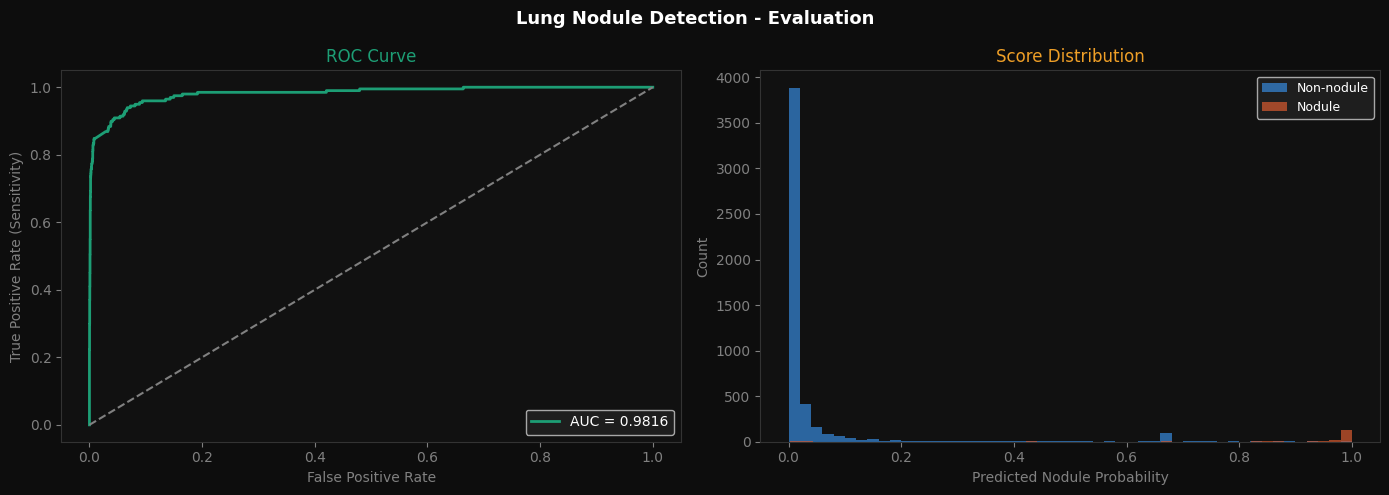


AUC: 0.9816
  Sensitivity 95%: FPR=0.0890, threshold=0.0835
  Sensitivity 90%: FPR=0.0414, threshold=0.3591
  Sensitivity 85%: FPR=0.0288, threshold=0.6782


In [39]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'lung_det')
OUT    = os.path.join(BASE, 'outputs', 'nb05_lung_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load best model
best_path = os.path.join(CKPT, 'lung_det_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, AUC={ckpt["best_auc"]:.4f})')

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for patches, labels in va_dl:
        patches = patches.to(DEVICE)
        logits  = model(patches)
        probs   = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
fig.suptitle('Lung Nodule Detection - Evaluation', color='white', fontsize=13, fontweight='bold')

# ROC curve
axes[0].plot(fpr, tpr, color='#1D9E75', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--')
axes[0].set_xlabel('False Positive Rate', color='gray')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', color='gray')
axes[0].set_title('ROC Curve', color=  '#1D9E75')
axes[0].legend(fontsize=10, facecolor='#222', labelcolor='white')
axes[0].set_facecolor('#111')
axes[0].spines[:].set_color('#333')
axes[0].tick_params(colors='gray')

# Score distribution
axes[1].hist(all_probs[all_labels==0], bins=50, alpha=0.7, color='#378ADD', label='Non-nodule')
axes[1].hist(all_probs[all_labels==1], bins=50, alpha=0.7, color='#D85A30', label='Nodule')
axes[1].set_xlabel('Predicted Nodule Probability', color='gray')
axes[1].set_ylabel('Count', color='gray')
axes[1].set_title('Score Distribution', color='#EF9F27')
axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
axes[1].set_facecolor('#111')
axes[1].spines[:].set_color('#333')
axes[1].tick_params(colors='gray')

plt.tight_layout()
fig_path = os.path.join(OUT, 'roc_curve.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

# Key thresholds
print(f'\nAUC: {roc_auc:.4f}')
for target_sens in [0.95, 0.90, 0.85]:
    idx = np.where(tpr >= target_sens)[0]
    if len(idx) > 0:
        fp_rate = fpr[idx[0]]
        thresh  = thresholds[idx[0]]
        print(f'  Sensitivity {target_sens:.0%}: FPR={fp_rate:.4f}, threshold={thresh:.4f}')

---
## Cell 10 - Training Curves

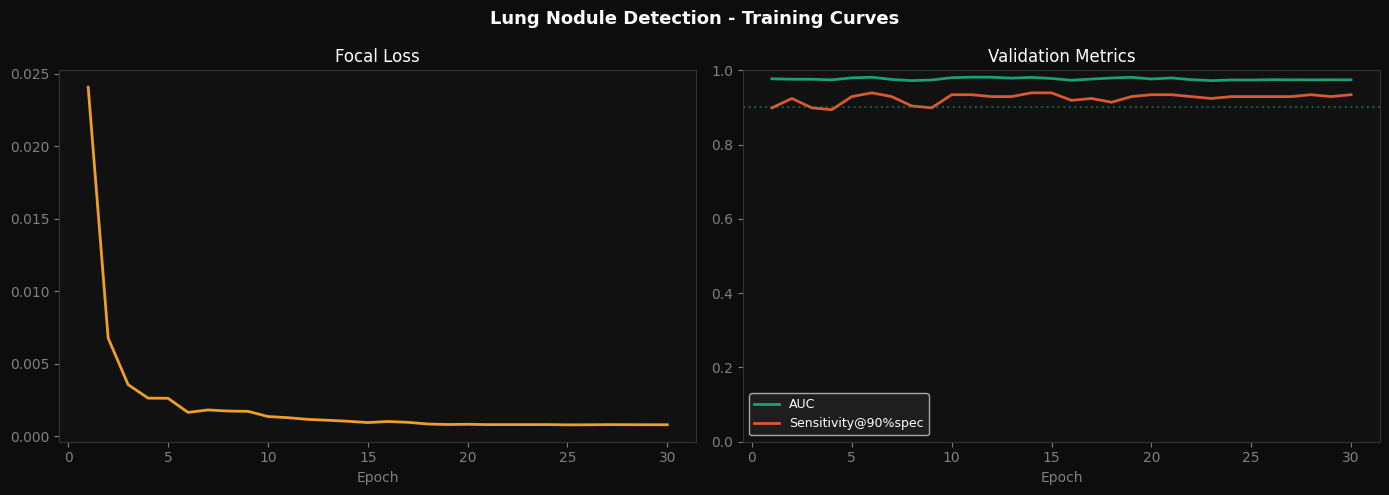

Best epoch   : 11
  AUC        : 0.9816  (target >0.90)
  Sensitivity: 0.9343


In [40]:
import os, torch
import matplotlib.pyplot as plt

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'lung_det')
OUT    = os.path.join(BASE, 'outputs', 'nb05_lung_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = os.path.join(CKPT, 'lung_det_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint - run training first')
else:
    history = torch.load(ckpt_path, map_location=DEVICE, weights_only=False).get('history', [])

    epochs     = [h['epoch']      for h in history]
    losses     = [h['train_loss'] for h in history]
    aucs       = [h['val_auc']    for h in history]
    sensitivities = [h['sensitivity'] for h in history]

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('Lung Nodule Detection - Training Curves',
                 color='white', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
    axes[0].set_title('Focal Loss', color='white')
    axes[0].set_xlabel('Epoch', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')

    axes[1].plot(epochs, aucs,          color='#1D9E75', linewidth=2, label='AUC')
    axes[1].plot(epochs, sensitivities, color='#D85A30', linewidth=2, label='Sensitivity@90%spec')
    axes[1].axhline(0.90, color='#1D9E75', linestyle=':', alpha=0.5)
    axes[1].set_title('Validation Metrics', color='white')
    axes[1].set_xlabel('Epoch', color='gray')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'training_curves.png'), dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

    best = max(history, key=lambda h: h['val_auc'])
    print(f'Best epoch   : {best["epoch"]}')
    print(f'  AUC        : {best["val_auc"]:.4f}  (target >0.90)')
    print(f'  Sensitivity: {best["sensitivity"]:.4f}')

---
## Cell 11 - ONNX Export

In [41]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'lung_det')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'lung_det_resnet3d.onnx')

best_path = os.path.join(BASE, 'checkpoints', 'lung_det', 'lung_det_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

model.eval()
model.cpu()
dummy = torch.zeros(1, 1, 32, 32, 32)

try:
    torch.onnx.export(
        model, dummy, onnx_path,
        export_params=True, opset_version=17,
        input_names=['patch'], output_names=['logits'],
        dynamic_axes={'patch': {0: 'batch_size'}}
    )
    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX export: {onnx_path}')
    print(f'Size       : {sz:.1f} MB')

    import onnx, onnxruntime as ort
    onnx.checker.check_model(onnx.load(onnx_path))
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'patch': dummy.numpy()})
    print(f'Inference OK: {out[0].shape}')
    print('ONNX OK')
except Exception as e:
    print(f'ONNX failed: {e}')
finally:
    model.to(DEVICE)

ONNX export: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\lung_det\lung_det_resnet3d.onnx
Size       : 27.3 MB
Inference OK: (1, 2)
ONNX OK


---
## Cell 12 - Summary

In [42]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'lung_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 65)
print('  NOTEBOOK 05 - LUNG NODULE DETECTION')
print('=' * 65)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'lung_det_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        m    = ckpt.get('metrics', {})
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'AUC={m.get("val_auc",0):.4f}, '
              f'sens={m.get("sensitivity",0):.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'lung_det', 'lung_det_resnet3d.onnx')
print(f'  ONNX : {"OK" if os.path.exists(onnx_p) else "not done yet"}')

print()
print('  Model     : 3D ResNet (NoduleDetector)')
print('  Loss      : Focal Loss (alpha=0.75, gamma=2.0)')
print('  Imbalance : 600:1 handled via WeightedRandomSampler')
print('  Metric    : AUC-ROC + Sensitivity @ 90% specificity')
print()
print('  After ONNX export verified:')
print('  - Delete LIDC-IDRI (124 GB) -- no longer needed')
print('  - Delete LUNA16 (111 GB)    -- no longer needed')
print('  - Frees 235 GB total')
print()
print('  Next: 06_Liver_Segmentation.ipynb')
print('=' * 65)

  NOTEBOOK 05 - LUNG NODULE DETECTION
  best  checkpoint: epoch  10, AUC=0.9816, sens=0.9343
  last  checkpoint: epoch  29, AUC=0.9746, sens=0.9343
  ONNX : OK

  Model     : 3D ResNet (NoduleDetector)
  Loss      : Focal Loss (alpha=0.75, gamma=2.0)
  Imbalance : 600:1 handled via WeightedRandomSampler
  Metric    : AUC-ROC + Sensitivity @ 90% specificity

  After ONNX export verified:
  - Delete LIDC-IDRI (124 GB) -- no longer needed
  - Delete LUNA16 (111 GB)    -- no longer needed
  - Frees 235 GB total

  Next: 06_Liver_Segmentation.ipynb
